In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Data Science environment initialized.")

✅ Data Science environment initialized.


In [2]:
import sys
# Ensure we can import from the parent directory for Brain A
sys.path.append(os.path.abspath('..'))

from model import ZeroTrustAutoencoder
from dataset_general import HubbleDataProcessor
from nlp_model import UrlNlpAutoencoder

# --- 1. Load Data ---
print("Loading Test Data...")
json_test = "../../data/raw/hubble_testing_data.json"

# Brain A Data
tabular_processor = HubbleDataProcessor(json_test)
tabular_processor.load_and_filter()
tabular_processor.engineer_features()
df_tabular = tabular_processor.get_dataframe()
tabular_tensor = torch.FloatTensor(df_tabular.values)

# Brain B Data
nlp_tensor_path = "../../data/processed/nlp/nlp_test_tensor.pt"
nlp_tensor = torch.load(nlp_tensor_path)

# Extract Labels (We will flag SQLi and Path Traversal for the plot)
raw_urls = []
labels = []
with open(json_test, 'r') as f:
    for line in f:
        if not line.strip(): continue
        try:
            event = json.loads(line)
            l7 = event.get("flow", {}).get("l7", {})
            if l7 and l7.get("type") != "RESPONSE":
                url = l7.get("http", {}).get("url", "")
                if url:
                    raw_urls.append(url)
                    # Simple heuristic to label attacks for the visualization
                    if "%27" in url or "OR" in url or "export" in url and len(url) > 60:
                        labels.append("Injection Attack")
                    else:
                        labels.append("Normal Traffic")
        except:
            continue

# --- 2. Load Models ---
print("Loading Brains...")
brain_a = ZeroTrustAutoencoder(input_dim=13)
brain_a.load_state_dict(torch.load("../../models/omnifinance/zerotrust_ae_v1.pth"))
brain_a.eval()

brain_b = UrlNlpAutoencoder(vocab_size=128, seq_length=150)
brain_b.load_state_dict(torch.load("../../models/omnifinance/nlp_ae_v1.pth"))
brain_b.eval()

# --- 3. Run Inference ---
print("Running Ensemble Inference...")
brain_a_scores = []
brain_b_scores = []

mse = nn.MSELoss(reduction='none')
ce = nn.CrossEntropyLoss(ignore_index=0, reduction='none')

with torch.no_grad():
    # Brain A Predictions
    recon_a = brain_a(tabular_tensor)
    loss_a = mse(recon_a, tabular_tensor).mean(dim=1).numpy()
    brain_a_scores = loss_a.tolist()
    
    # Brain B Predictions
    for i in range(len(nlp_tensor)):
        row_b = nlp_tensor[i].unsqueeze(0)
        logits = brain_b(row_b).transpose(1, 2)
        loss_b = ce(logits, row_b)
        
        mask = row_b != 0
        if mask.sum().item() > 0:
            seq_loss = loss_b.sum().item() / mask.sum().item()
        else:
            seq_loss = 0.0
        brain_b_scores.append(seq_loss)

# Compile into a DataFrame
results_df = pd.DataFrame({
    'URL': raw_urls[:len(brain_b_scores)], # Ensure lengths match
    'Label': labels[:len(brain_b_scores)],
    'Brain_A_Loss': brain_a_scores[:len(brain_b_scores)],
    'Brain_B_Loss': brain_b_scores
})

print(f"✅ Data compiled! {len(results_df)} packets ready for visualization.")

Loading Test Data...
🐝 Loading raw Hubble logs from ../../data/raw/hubble_testing_data.json...
✅ Filtered down to 86 pure, relevant network events.
🧠 Engineered Universal Feature Matrix: 13 dimensions.
Loading Brains...
Running Ensemble Inference...
✅ Data compiled! 86 packets ready for visualization.


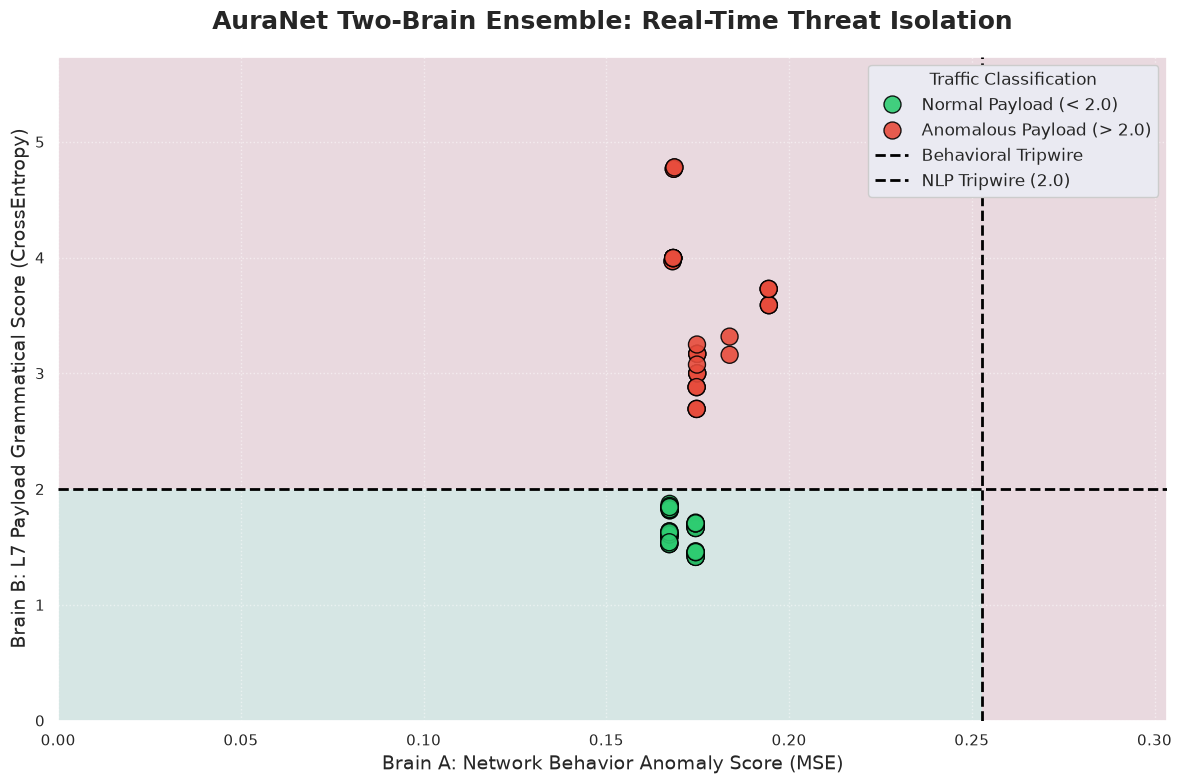

In [6]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = plt.gca()

# --- 1. Hardcoded Tripwires ---
# Set exactly to 2.0 to match the evaluate.py alert logic
GRAMMATICAL_TRIPWIRE = 2.0  
# Place the behavioral tripwire safely past your normal traffic cluster
BEHAVIORAL_TRIPWIRE = results_df['Brain_A_Loss'].max() * 1.3 

# --- 2. Enforce Strict Labeling Based on the 2.0 Threshold ---
results_df['Plot_Label'] = results_df['Brain_B_Loss'].apply(
    lambda x: 'Anomalous Payload (> 2.0)' if x > GRAMMATICAL_TRIPWIRE else 'Normal Payload (< 2.0)'
)

# --- 3. The Scatter Plot ---
sns.scatterplot(
    data=results_df, 
    x='Brain_A_Loss', 
    y='Brain_B_Loss', 
    hue='Plot_Label', 
    palette={"Normal Payload (< 2.0)": "#2ecc71", "Anomalous Payload (> 2.0)": "#e74c3c"},
    s=150, 
    edgecolor='black',
    alpha=0.9,
    zorder=5 
)

# --- 4. Draw the Tripwires ---
plt.axvline(x=BEHAVIORAL_TRIPWIRE, color='black', linestyle='--', linewidth=2, label='Behavioral Tripwire', zorder=4)
plt.axhline(y=GRAMMATICAL_TRIPWIRE, color='black', linestyle='--', linewidth=2, label=f'NLP Tripwire ({GRAMMATICAL_TRIPWIRE})', zorder=4)

# --- 5. Clean Zone Shading ---
x_min, x_max_plot = 0, BEHAVIORAL_TRIPWIRE * 1.2
y_min, y_max_plot = 0, results_df['Brain_B_Loss'].max() * 1.2

ax.set_xlim(x_min, x_max_plot)
ax.set_ylim(y_min, y_max_plot)

# Safe Zone (Bottom Left)
ax.add_patch(patches.Rectangle((0, 0), BEHAVIORAL_TRIPWIRE, GRAMMATICAL_TRIPWIRE, 
                               linewidth=0, facecolor='#2ecc71', alpha=0.1, zorder=0))

# Grammatical Danger Zone (Top Left)
ax.add_patch(patches.Rectangle((0, GRAMMATICAL_TRIPWIRE), BEHAVIORAL_TRIPWIRE, y_max_plot - GRAMMATICAL_TRIPWIRE, 
                               linewidth=0, facecolor='#e74c3c', alpha=0.1, zorder=0))

# Behavioral Danger Zone (Right Side)
ax.add_patch(patches.Rectangle((BEHAVIORAL_TRIPWIRE, 0), x_max_plot - BEHAVIORAL_TRIPWIRE, y_max_plot, 
                               linewidth=0, facecolor='#e74c3c', alpha=0.1, zorder=0))

# --- 6. Formatting ---
plt.title("AuraNet Two-Brain Ensemble: Real-Time Threat Isolation", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Brain A: Network Behavior Anomaly Score (MSE)", fontsize=14)
plt.ylabel("Brain B: L7 Payload Grammatical Score (CrossEntropy)", fontsize=14)

plt.legend(title="Traffic Classification", fontsize=12, title_fontsize=12, loc='upper right', framealpha=1.0)
plt.grid(True, linestyle=':', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

Not so great separation ration but we can work with this in addition to our second brain